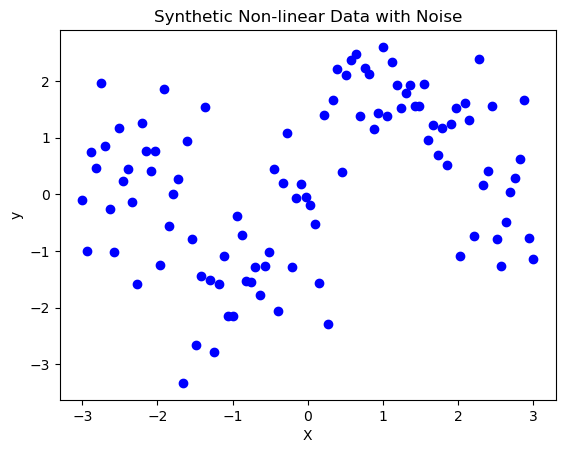

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(2026)

# # Synthetic non-linear data with lots of noise
X = np.linspace(-3, 3, 100)
y = np.sin(X) + np.sin(2*X) + np.random.normal(0.2, 1, X.shape)

# Plot
plt.scatter(X, y, color='blue', label='Data points')
plt.title('Synthetic Non-linear Data with Noise')
plt.xlabel('X')
plt.ylabel('y')
plt.show()

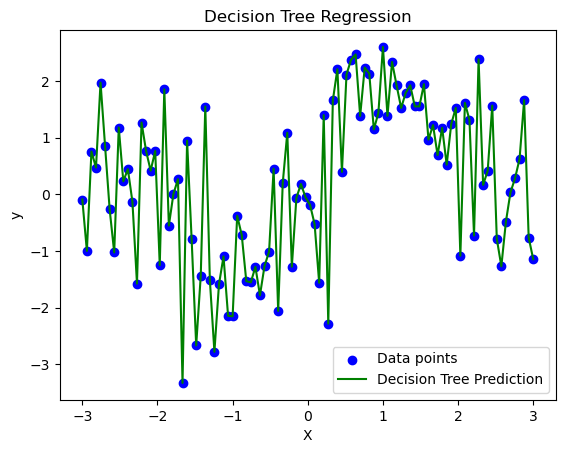

In [3]:
# Train decision tree regressor
from sklearn.tree import DecisionTreeRegressor
tree_reg = DecisionTreeRegressor(max_depth=None)
tree_reg.fit(X.reshape(-1, 1), y)
y_tree_pred = tree_reg.predict(X.reshape(-1, 1))

# Plot predictions
plt.scatter(X, y, color='blue', label='Data points')
plt.plot(X, y_tree_pred, color='green', label='Decision Tree Prediction')
plt.title('Decision Tree Regression')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

In [ ]:
# Bootstrap sampling function
def bootstrap_sample(X, y):
    n_samples = X.shape[0]
    indices = np.random.randint(0, n_samples, n_samples) # Sample with replacement
    prop_samples_out_of_bag = len(set(range(n_samples)) - set(indices)) / n_samples
    return X[indices], y[indices], prop_samples_out_of_bag

# Example of bootstrap sampling
X_sample, y_sample, oob_prop = bootstrap_sample(X, y)
print(f'% of out-of-bag samples: {oob_prop * 100:.1f}%')

% of out-of-bag samples: 40.0%


Average % of out-of-bag samples in 100 trees: 36.4%


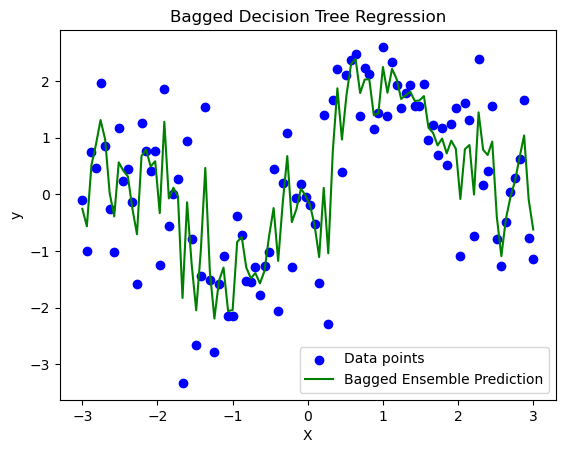

In [ ]:
# Train bagged ensemble of decision trees
n_trees = 100
oob_props = []
y_pred_ensemble = np.zeros((n_trees, X.shape[0]))
for i in range(n_trees):
    X_sample, y_sample, prop_samples_out_of_bag = bootstrap_sample(X.reshape(-1, 1), y)
    oob_props.append(prop_samples_out_of_bag)
    tree = DecisionTreeRegressor(max_depth=None)
    tree.fit(X_sample, y_sample)
    y_pred_ensemble[i] = tree.predict(X.reshape(-1, 1))

y_ensemble_pred = np.mean(y_pred_ensemble, axis=0)
print(f'Average % of out-of-bag samples in {n_trees} trees: {np.mean(oob_props) * 100:.1f}%')

# Plot ensemble predictions
plt.scatter(X, y, color='blue', label='Data points')
plt.plot(X, y_ensemble_pred, color='green', label='Bagged Ensemble Prediction')
plt.title('Bagged Decision Tree Regression')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

In [10]:
# Create pure sin data
X_pure = np.linspace(-3, 3, 100)
y_pure = np.sin(X_pure) + np.sin(2*X_pure)

# Train bagging regressor
from sklearn.ensemble import BaggingRegressor

bagging_regressor = BaggingRegressor(n_estimators=100, random_state=2026)
bagging_regressor.fit(X.reshape(-1, 1), y)

# Compare DecisionTreeRegressor and BaggingRegressor error
from sklearn.metrics import mean_squared_error

# Calculate MSE for both models
mse_dt = mean_squared_error(y_pure, tree_reg.predict(X_pure.reshape(-1, 1)))
mse_bagging = mean_squared_error(y_pure, bagging_regressor.predict(X_pure.reshape(-1, 1)))

print(f"Decision Tree MSE: {mse_dt:.4f}")
print(f"Bagging Regressor MSE: {mse_bagging:.4f}")



Decision Tree MSE: 1.0892
Bagging Regressor MSE: 0.4454


In [11]:
# Create noisy sin data
X_noisy = np.linspace(-3, 3, 100)
y_noisy = np.sin(X_noisy) + np.sin(2*X_noisy) + np.random.normal(0.2, 1, X.shape)

# Train bagging regressor
from sklearn.ensemble import BaggingRegressor

bagging_regressor = BaggingRegressor(n_estimators=100, random_state=2026)
bagging_regressor.fit(X.reshape(-1, 1), y)

# Compare DecisionTreeRegressor and BaggingRegressor error
from sklearn.metrics import mean_squared_error

# Calculate MSE for both models
mse_dt = mean_squared_error(y_noisy, tree_reg.predict(X_noisy.reshape(-1, 1)))
mse_bagging = mean_squared_error(y_noisy, bagging_regressor.predict(X_noisy.reshape(-1, 1)))

print(f"Decision Tree MSE: {mse_dt:.4f}")
print(f"Bagging Regressor MSE: {mse_bagging:.4f}")



Decision Tree MSE: 2.3280
Bagging Regressor MSE: 1.3070
